In [58]:
import cv2
import inspect
src_file_path = '/home/vboxuser/VisionForStewart/XDetection/'
import numpy as np
from skimage.exposure import match_histograms
import matplotlib.pyplot as plt
import os
import sys
TRIANGULATION_DIR = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'Triangulation'))
sys.path.append(TRIANGULATION_DIR)
CIRCLE_DIR = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'CircleDetection'))
sys.path.append(CIRCLE_DIR)
DETECT_AND_FIND_CONTOUR = os.path.abspath(os.path.join(os.path.dirname(src_file_path), '..', 'DetectAndFindContour'))
sys.path.append(DETECT_AND_FIND_CONTOUR)
import triangulate_pts
import contour_det_lib
import AllSteps

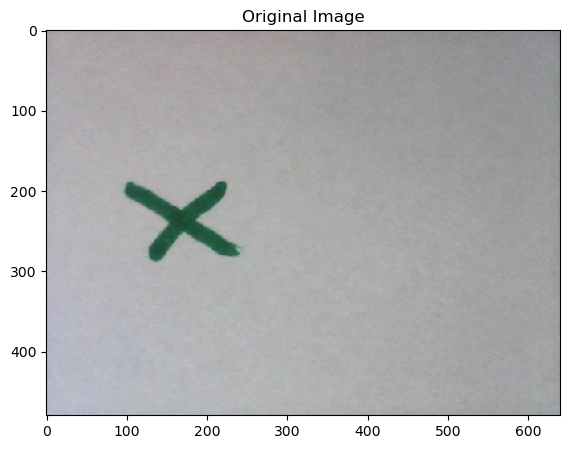

In [59]:
img = cv2.imread("xPaper.png")
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.show()

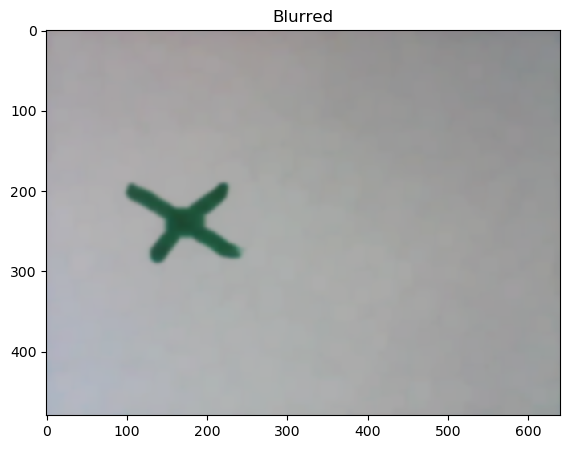

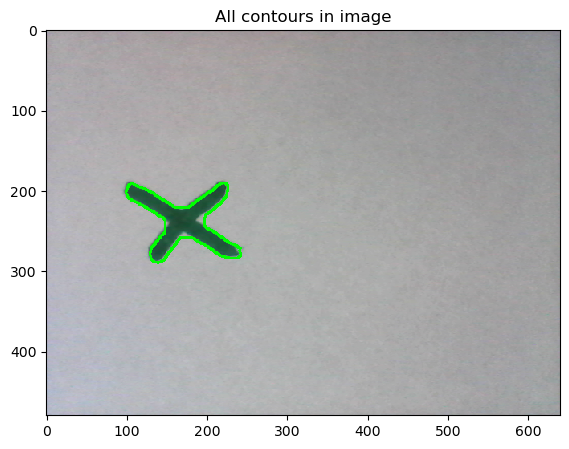

In [60]:
#Finding contours in whole image
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

kernel = np.ones((8,8),np.uint8)
closing = cv2.morphologyEx(img,cv2.MORPH_OPEN, kernel, iterations = 2)
blurred = cv2.GaussianBlur(closing, (9,9), 2)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title("Blurred")
plt.show()

edges = cv2.Canny(blurred,0,40, apertureSize=3, L2gradient=True)

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contInImg = img.copy()
cv2.drawContours(contInImg, contours, -1, (0, 255, 0), 2)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(contInImg, cv2.COLOR_BGR2RGB))
plt.title("All contours in image")
plt.show()


Text(0.5, 1.0, 'Masked Image')

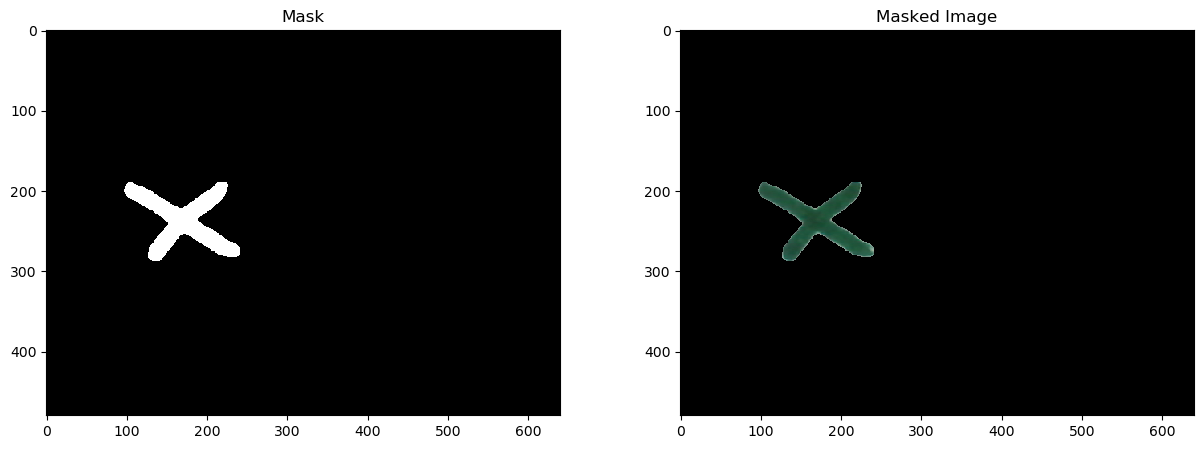

In [61]:
low_hsv_val = np.array([40, 30, 0])
high_hsv_val = np.array([99, 255, 255])
mask = AllSteps.find_hsv_mask(img, low_hsv_val, high_hsv_val, blur=True)
#mask = cv2.medianBlur(mask, 5)
masked_img = AllSteps.apply_hsv_mask(img, mask)
# Show images
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))
plt.title("Mask")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
plt.title("Masked Image")

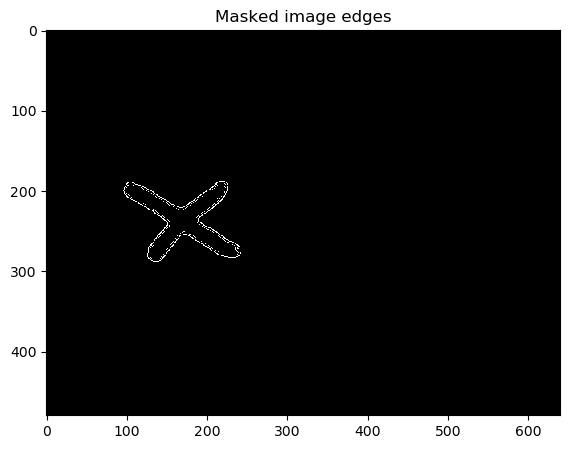

In [62]:
blurred = cv2.medianBlur(masked_img, 9)
grey = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(grey,0,40, apertureSize=3, L2gradient=True)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.title("Masked image edges")
plt.show()


Text(0.5, 1.0, 'Contours on masked Image')

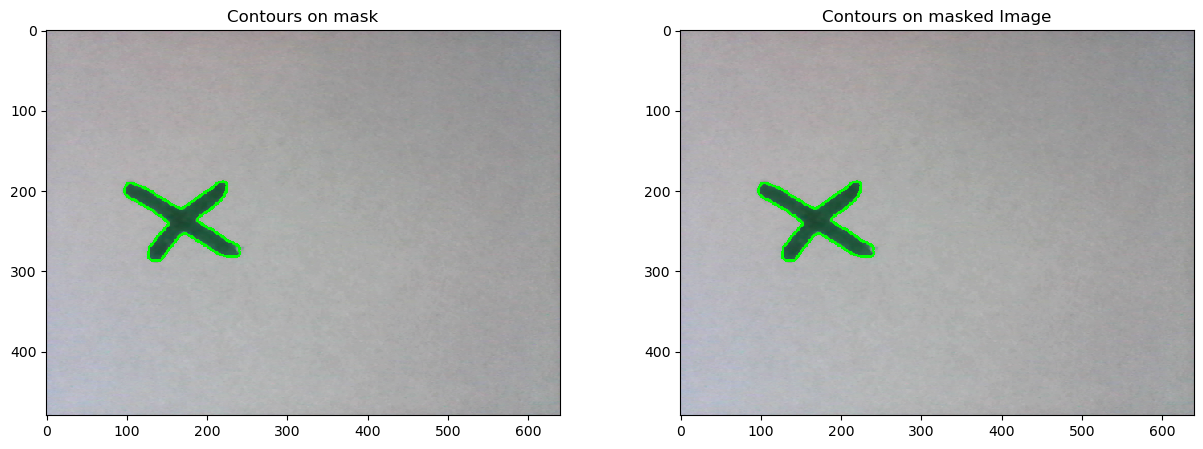

In [63]:
#Contour detection on masked vs masked image
contours_mask, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
grey = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
contours_masked_image, _ = cv2.findContours(grey, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
maskContours = img.copy()
maskedImgContours = img.copy()
cv2.drawContours(maskContours, contours_mask, -1, (0, 255, 0), 2)
cv2.drawContours(maskedImgContours, contours_masked_image, -1, (0, 255, 0), 2)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(maskContours, cv2.COLOR_BGR2RGB))
plt.title("Contours on mask")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(maskedImgContours, cv2.COLOR_BGR2RGB))
plt.title("Contours on masked Image")
#Contours detected on the mask vs on the masked image look pretty much the same

0


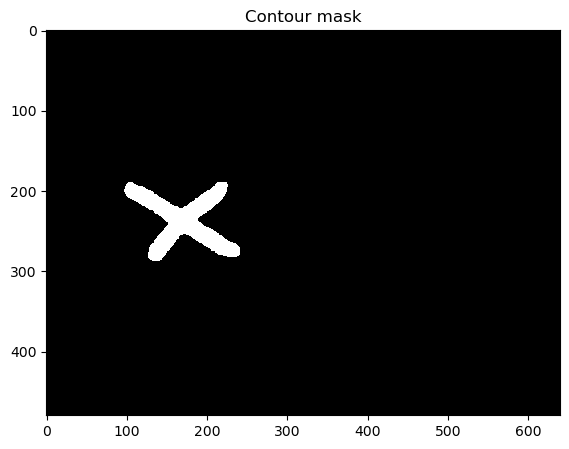

Text(0.5, 1.0, 'Contours and centers')

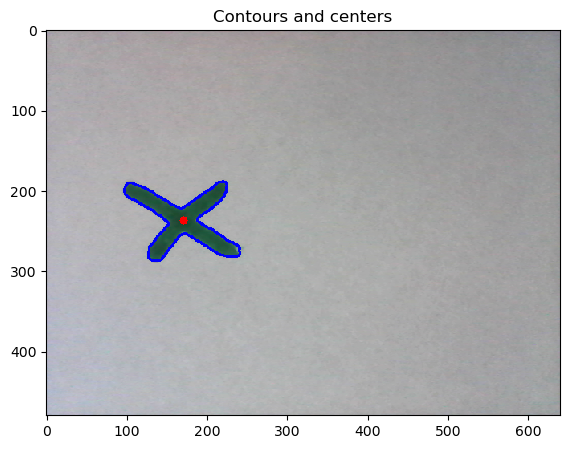

In [64]:
result_image = img.copy()
centers = []

for i, cnt in enumerate(contours_mask):
    area = cv2.contourArea(cnt)
    if area < 500:
        continue  # Filter out noise
    print(i)
    # Draw the raw contour
    cv2.drawContours(result_image, [cnt], -1, (255, 0, 0), 2)

    # Get centroid
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        continue
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    centers.append((cx, cy))

    # Draw center point
    cv2.circle(result_image, (cx, cy), 5, (0, 0, 255), -1)

    # Show individual contour mask (optional)
    temp_mask = np.zeros_like(mask)
    cv2.drawContours(temp_mask, [cnt], -1, 255, -1)
    #cv2.imshow(f"Contour Mask {i}", temp_mask)
    plt.figure(figsize=(15,5))
    #plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(temp_mask, cv2.COLOR_BGR2RGB))
    plt.title("Contour mask")
    plt.show()

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("Contours and centers")



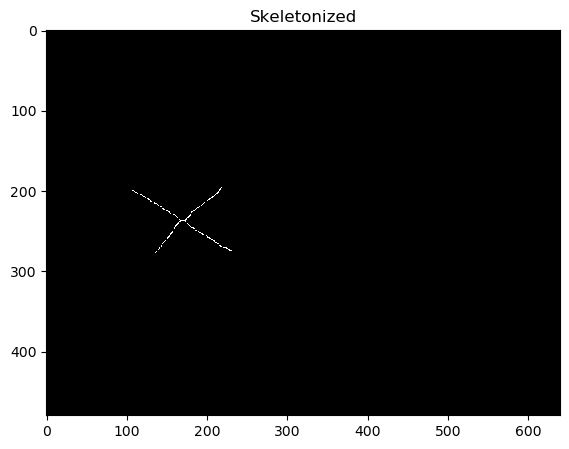

In [65]:
thin = cv2.ximgproc.thinning(mask)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(thin, cv2.COLOR_BGR2RGB))
plt.title("Skeletonized")
plt.show()

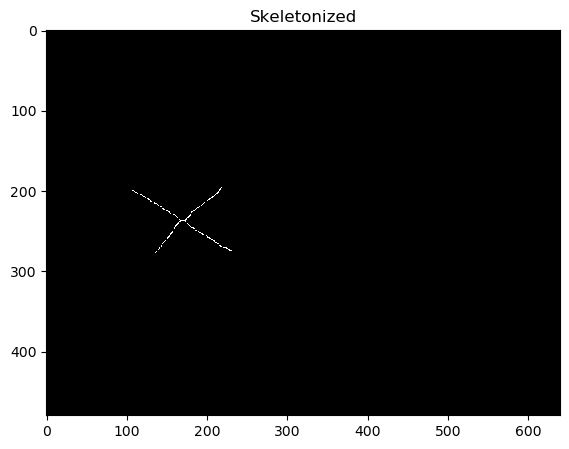

In [66]:
#This thinning is better and removes noise
clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
thin2 = cv2.ximgproc.thinning(clean)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(thin2, cv2.COLOR_BGR2RGB))
plt.title("Skeletonized")
plt.show()

Center (mean): (173, 235)


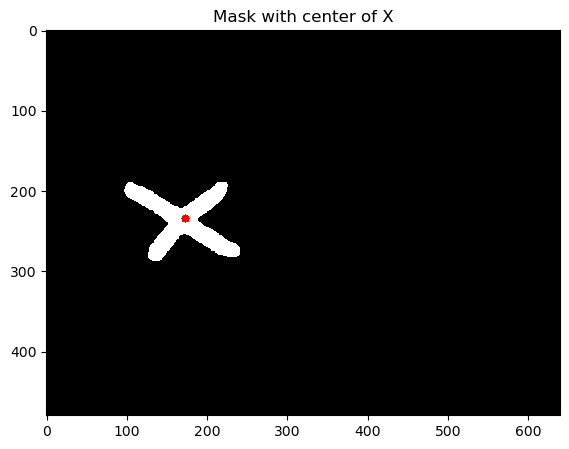

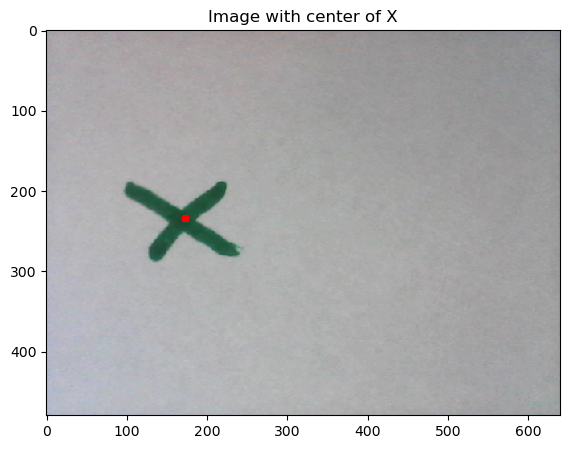

In [67]:
coloredDisplayOfMask = mask.copy()
coloredDisplayOfMask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
imgCopyWithCenter = img.copy()
#Getting geometric center of skeleton points
ys, xs = np.where(thin2 > 0)
if len(xs) > 0:
    center = (int(np.mean(xs)), int(np.mean(ys)))
    cv2.circle(coloredDisplayOfMask, center, 5, (0, 0, 255), -1)
    cv2.circle(imgCopyWithCenter, center, 5, (0, 0, 255), -1)
    print(f"Center (mean): {center}")
else:
    print("No skeleton pixels found")

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(coloredDisplayOfMask, cv2.COLOR_BGR2RGB))
plt.title("Mask with center of X")
plt.show()

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(imgCopyWithCenter, cv2.COLOR_BGR2RGB))
plt.title("Image with center of X")
plt.show()

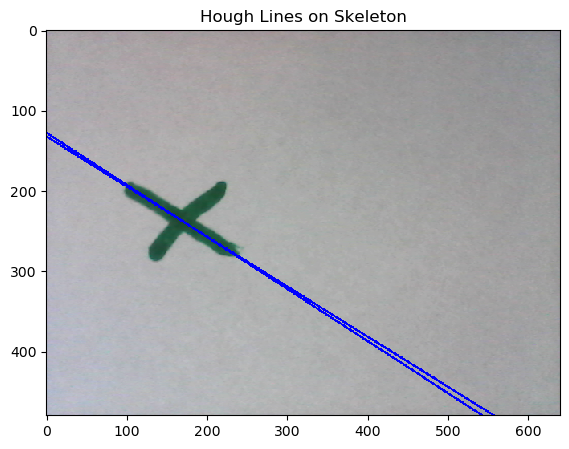

In [68]:
# --- Try HoughLines on skeleton ---
hLinesOnImg = img.copy()
lines = cv2.HoughLines(thin2, 1, np.pi / 180, 50)

if lines is not None:
    for rho_theta in lines[:10]:  # Show up to 10 lines
        rho, theta = rho_theta[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(hLinesOnImg, pt1, pt2, (255, 0, 0), 2)
else:
    print("No lines detected.")

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(hLinesOnImg, cv2.COLOR_BGR2RGB))
plt.title("Hough Lines on Skeleton")
plt.show()
#Well this was a fail


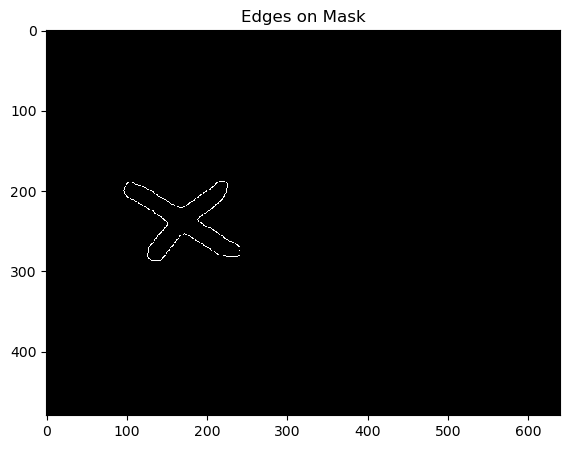

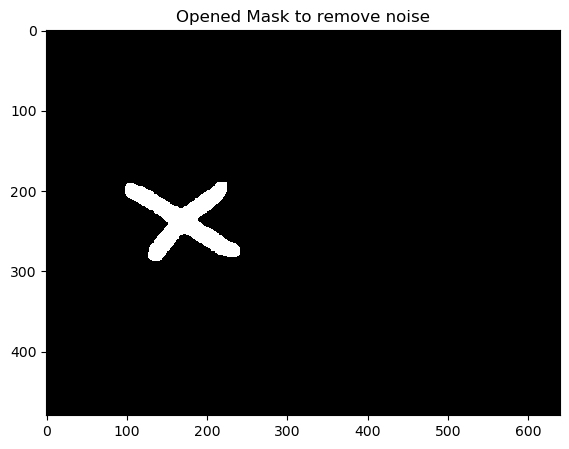

(480, 640) uint8


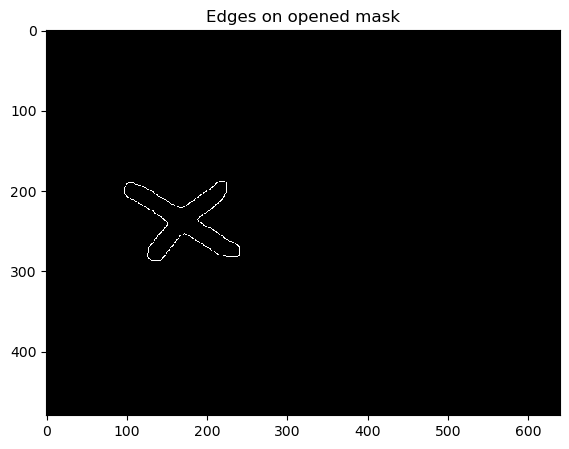

(480, 640) uint8


In [69]:
#How about finding lines on mask edges
edges = cv2.Canny(mask, 50, 150)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.title("Edges on Mask")
plt.show()
kernel = np.ones((7,7), np.uint8)
# Apply morphological opening to try to remove noise
opened_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(opened_mask, cv2.COLOR_BGR2RGB))
plt.title("Opened Mask to remove noise")
plt.show()



edges = cv2.Canny(opened_mask, 50, 150)

print(edges.shape, edges.dtype)

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.title("Edges on opened mask")
plt.show()

print(edges.shape, edges.dtype)

In [70]:
print(edges.shape, edges.dtype)

(480, 640) uint8


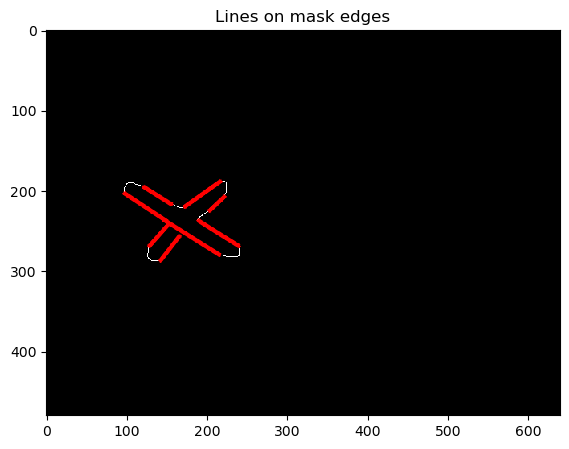

In [71]:
# Use HoughLinesP to get line segments
linesOnMaskedEdges = edges.copy()
linesOnMaskedEdges = cv2.cvtColor(linesOnMaskedEdges, cv2.COLOR_GRAY2BGR)
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=30, minLineLength=0, maxLineGap=20)
#lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=30)
if lines is not None:
    for i in range(0, len(lines)):
        l = lines[i][0]
        cv2.line(linesOnMaskedEdges, (l[0], l[1]), (l[2], l[3]), (0,0,255), 3, cv2.LINE_AA)

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(linesOnMaskedEdges, cv2.COLOR_BGR2RGB))
plt.title("Lines on mask edges")
plt.show()

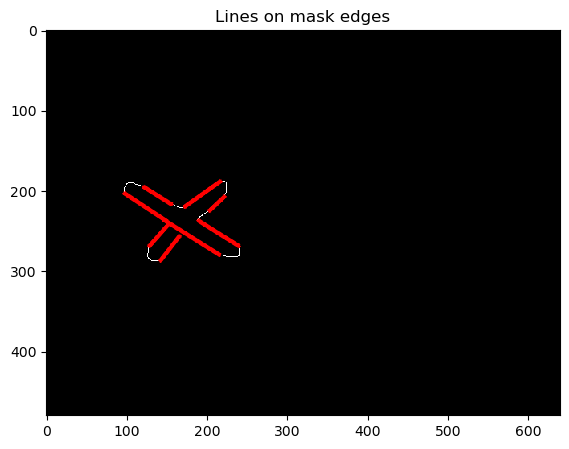

In [72]:
# Use HoughLinesP to get line segments
linesOnMaskedEdges2 = edges.copy()
linesOnMaskedEdges2 = cv2.cvtColor(linesOnMaskedEdges2, cv2.COLOR_GRAY2BGR)
#lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=30, minLineLength=0, maxLineGap=20)
lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=30)
#print(lines)
if lines is not None:
    for i in range(0, len(lines)):
        l = lines[i][0]
        cv2.line(linesOnMaskedEdges2, pt1, pt2, (255, 0, 0), 2)

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(linesOnMaskedEdges, cv2.COLOR_BGR2RGB))
plt.title("Lines on mask edges")
plt.show()

[]

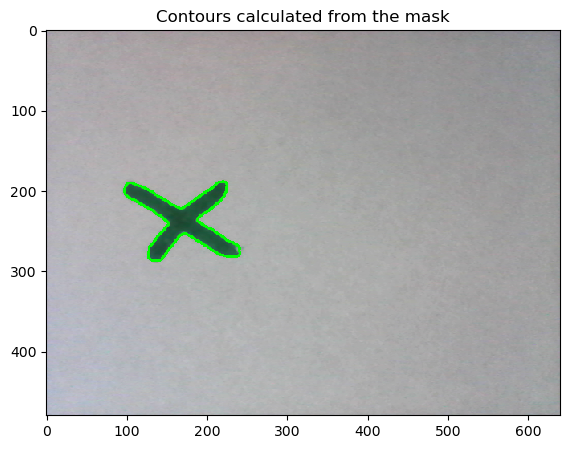

In [73]:
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(maskContours, cv2.COLOR_BGR2RGB))
plt.title("Contours calculated from the mask")
plt.plot()



In [74]:
#Lets say we have the contour representing the X, here I assume that the X is the largest contour in the image. I may also have to combine contours in real scenario
filtered = [c for c in contours_mask if cv2.contourArea(c) > 200]

# Optionally sort and pick biggest
best_contour = sorted(filtered, key=cv2.contourArea, reverse=True)[0]
points = cnt.reshape(-1, 2)
#print(points)

In [75]:
def fit_line_through_points(points):
    # Use OpenCV fitLine to get the line in vector form
    [vx, vy, x0, y0] = cv2.fitLine(points, cv2.DIST_L2, 0, 0.01, 0.01)
    return vx, vy, x0, y0

In [76]:
def draw_line(img, line, color):
    vx, vy, x0, y0 = line
    x0 = x0[0]
    y0 = y0[0]
    pt1 = (int(x0 - vx[0]*1000), int(y0 - vy[0]*1000))
    pt2 = (int(x0 + vx[0]*1000), int(y0 + vy[0]*1000))
    cv2.line(img, pt1, pt2, color, 2)

In [77]:
from sklearn.cluster import KMeans

#Cluster the points in the contour
kmeans = KMeans(n_clusters=2).fit(points)
labels = kmeans.labels_

#Find two best lines
points1 = points[labels==0]
points2 = points[labels==1]

#Fit a line
line1 = fit_line_through_points(points1)
line2 = fit_line_through_points(points2)

/home/vboxuser/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[]

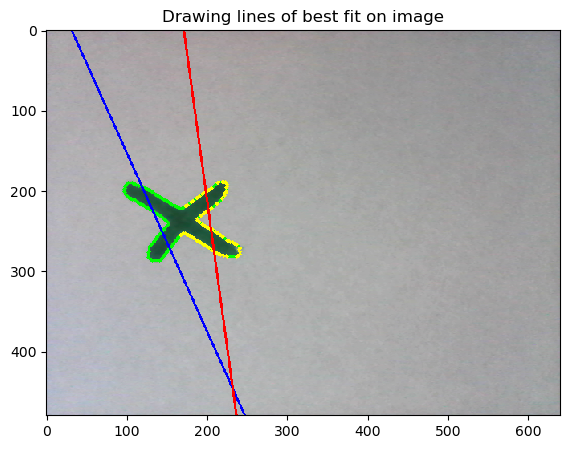

In [78]:
displayLinesPts1 = maskContours.copy()
# Draw clustered points
for pt in points1:
    cv2.circle(displayLinesPts1, tuple(pt), 2, (0, 255, 0), -1)  # Green for cluster 1

for pt in points2:
    cv2.circle(displayLinesPts1, tuple(pt), 2, (0, 255, 255), -1)  # Yellow for cluster 2
draw_line(displayLinesPts1, line1, (255,0,0))

draw_line(displayLinesPts1, line2, (0,0,255))

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(displayLinesPts1, cv2.COLOR_BGR2RGB))
plt.title("Drawing lines of best fit on image")
plt.plot()

In [79]:
from sklearn.decomposition import PCA
def compute_local_orientations(points, window_size=5):
    orientations = []
    valid_points = []

    for i in range(len(points)):
        #Get neighborhood
        start = max(i - window_size, 0)
        end = min(i + window_size + 1, len(points))
        neighborhood = points[start:end]

        if len(neighborhood) < 2:
            continue
        
        #Use PCA to get direction
        pca = PCA(n_components=2)
        pca.fit(neighborhood)
        direction = pca.components_[0]

        #Angle of the principal direction
        angle = np.arctan2(direction[1], direction[0])
        orientations.append([angle])
        valid_points.append(points[i])
    return np.array(valid_points), np.array(orientations)


In [80]:
# Assume `points` is Nx2 array of contour points
valid_points, orientations = compute_local_orientations(points)

# Cluster based on orientation
kmeans = KMeans(n_clusters=2).fit(orientations)
labels = kmeans.labels_

# Separate points into two clusters
points1 = valid_points[labels == 0]
points2 = valid_points[labels == 1]

/home/vboxuser/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[]

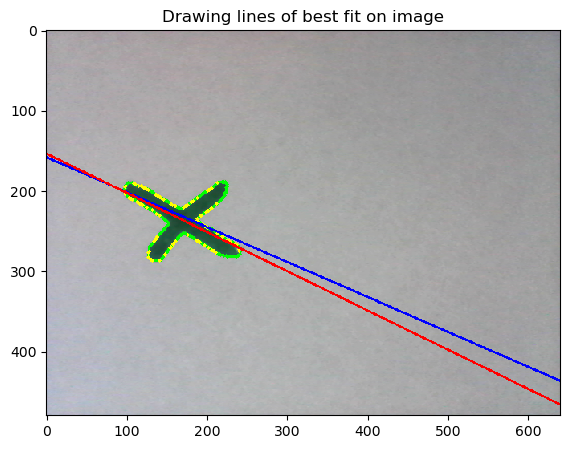

In [81]:
displayLinesPts2 = maskContours.copy()
# Draw clustered points
for pt in points1:
    cv2.circle(displayLinesPts2, tuple(pt), 2, (0, 255, 0), -1)  # Green for cluster 1

for pt in points2:
    cv2.circle(displayLinesPts2, tuple(pt), 2, (0, 255, 255), -1)  # Yellow for cluster 2

# Fit lines and draw
line1 = fit_line_through_points(points1)
line2 = fit_line_through_points(points2)

draw_line(displayLinesPts2, line1, (255, 0, 0))  # blue
draw_line(displayLinesPts2, line2, (0, 0, 255))  # red

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(displayLinesPts2, cv2.COLOR_BGR2RGB))
plt.title("Drawing lines of best fit on image")
plt.plot()
#This does not seem to work that well still. The clustering is not clean enough for consistent lines

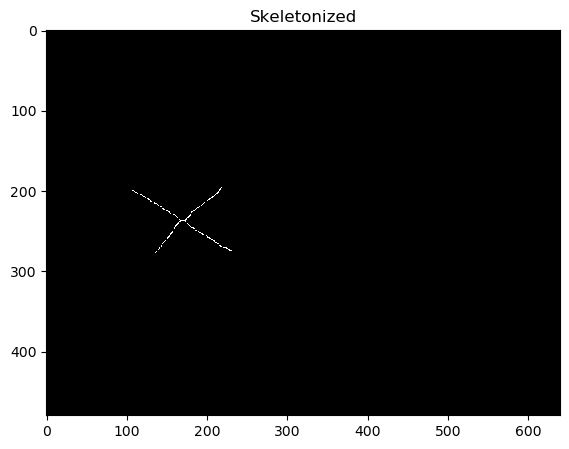

/home/vboxuser/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [82]:
#Trying with the skeletonized version
#This thinning is better and removes noise
clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
skeleton = cv2.ximgproc.thinning(clean)
plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(skeleton, cv2.COLOR_BGR2RGB))
plt.title("Skeletonized")
plt.show()

# Assume `skeleton` is a binary image (0s and 255s) after thinning
skeleton_points = np.column_stack(np.where(skeleton > 0))
skeleton_points = skeleton_points[:, ::-1]  # Change to (x, y) format
# Assume `points` is Nx2 array of contour points
valid_skeleton_points, skeleton_point_orientations = compute_local_orientations(skeleton_points)

# Cluster based on orientation
kmeans = KMeans(n_clusters=2).fit(skeleton_point_orientations)
labels = kmeans.labels_

# Separate points into two clusters
skele_points1 = valid_skeleton_points[labels == 0]
skele_points2 = valid_skeleton_points[labels == 1]

[]

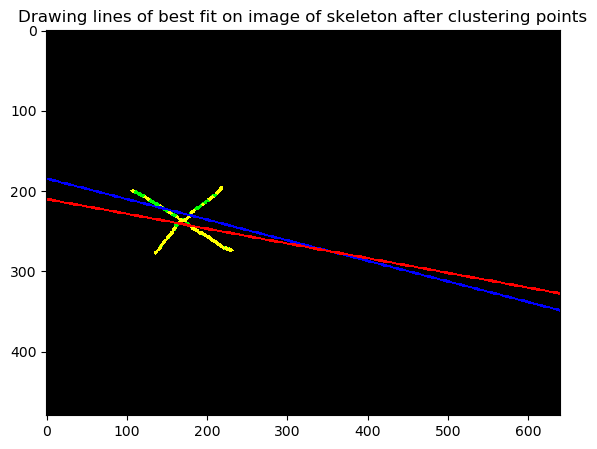

In [83]:
displaySkeletonPts = skeleton.copy()
displaySkeletonPts = cv2.cvtColor(displaySkeletonPts, cv2.COLOR_GRAY2BGR)
# Draw clustered points
for pt in skele_points1:
    cv2.circle(displaySkeletonPts, tuple(pt), 2, (0, 255, 0), -1)  # Green for cluster 1

for pt in skele_points2:
    cv2.circle(displaySkeletonPts, tuple(pt), 2, (0, 255, 255), -1)  # Yellow for cluster 2

# Fit lines and draw
line1 = fit_line_through_points(skele_points1)
line2 = fit_line_through_points(skele_points2)

draw_line(displaySkeletonPts, line1, (255, 0, 0))  # blue
draw_line(displaySkeletonPts, line2, (0, 0, 255))  # red

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(displaySkeletonPts, cv2.COLOR_BGR2RGB))
plt.title("Drawing lines of best fit on image of skeleton after clustering points")
plt.plot()

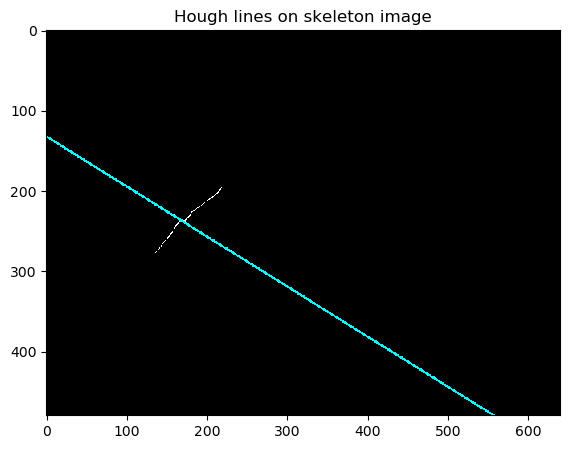

3159


In [84]:
# Use HoughLines to get line segments
linesOnSkeleton = skeleton.copy()
linesOnSkeleton = cv2.cvtColor(linesOnSkeleton, cv2.COLOR_GRAY2BGR)
#lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=30, minLineLength=0, maxLineGap=20)
lines = cv2.HoughLines(thin, 1, np.pi / 180, threshold=1)
#print(lines)
if lines is not None:
    for i in range(0, len(lines)):
        l = lines[i][0]
        cv2.line(linesOnSkeleton, pt1, pt2, (255, 0 + i * 2, 0), 2)

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(linesOnSkeleton, cv2.COLOR_BGR2RGB))
plt.title("Hough lines on skeleton image")
plt.show()

print(len(lines))

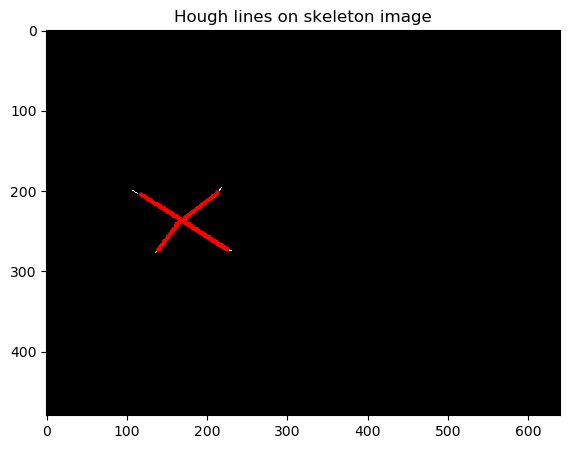

4


In [ ]:
# Use HoughLinesP to get line segments
linesOnSkeleton = skeleton.copy()
linesOnSkeleton = cv2.cvtColor(linesOnSkeleton, cv2.COLOR_GRAY2BGR)
lines = cv2.HoughLinesP(skeleton, 1, np.pi / 180, threshold=30, minLineLength=10, maxLineGap=20)
#print(lines)
if lines is not None:
    for i in range(0, len(lines)):
        l = lines[i][0]
        cv2.line(linesOnSkeleton, (l[0], l[1]), (l[2], l[3]), (0,10*i,255), 3, cv2.LINE_AA)

plt.figure(figsize=(15,5))
plt.imshow(cv2.cvtColor(linesOnSkeleton, cv2.COLOR_BGR2RGB))
plt.title("Hough lines on skeleton image")
plt.show()

print(len(lines))